# Data Exploration Notebook

## Libraries

In [10]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.image import imread

## Training data

In [2]:
training_path = "data/train.csv"

training_df = pd.read_csv(training_path)
training_df.head()

,Image_Label,EncodedPixels
0,0011165.jpg_Fish,264918 937 266318 937 267718 937 269118 937 27...
1,0011165.jpg_Flower,1355565 1002 1356965 1002 1358365 1002 1359765...
2,0011165.jpg_Gravel,NaN
3,0011165.jpg_Sugar,NaN
4,002be4f.jpg_Fish,233813 878 235213 878 236613 878 238010 881 23...


In [3]:
training_df[["Image", "Label"]] = training_df["Image_Label"].str.split("_", expand = True)
training_df = training_df[["Image", "Label", "EncodedPixels"]]
training_df.fillna("", inplace = True)
training_df.head()

,Image,Label,EncodedPixels
0,0011165.jpg,Fish,264918 937 266318 937 267718 937 269118 937 27...
1,0011165.jpg,Flower,1355565 1002 1356965 1002 1358365 1002 1359765...
2,0011165.jpg,Gravel,
3,0011165.jpg,Sugar,
4,002be4f.jpg,Fish,233813 878 235213 878 236613 878 238010 881 23...


In [4]:
pivot_training_df = training_df.pivot(index = "Image", columns = "Label", values = "EncodedPixels")
pivot_training_df.head()

Label,Fish,Flower,Gravel,Sugar
Image,,,,
0011165.jpg,264918 937 266318 937 267718 937 269118 937 27...,1355565 1002 1356965 1002 1358365 1002 1359765...,,
002be4f.jpg,233813 878 235213 878 236613 878 238010 881 23...,1339279 519 1340679 519 1342079 519 1343479 51...,,67495 350 68895 350 70295 350 71695 350 73095 ...
0031ae9.jpg,3510 690 4910 690 6310 690 7710 690 9110 690 1...,2047 703 3447 703 4847 703 6247 703 7647 703 9...,,658170 388 659570 388 660970 388 662370 388 66...
0035239.jpg,,100812 462 102212 462 103612 462 105012 462 10...,65400 380 66800 380 68200 380 69600 380 71000 ...,
003994e.jpg,2367966 18 2367985 2 2367993 8 2368002 62 2369...,,353317 416 354717 416 356117 416 357517 416 35...,28011 489 29411 489 30811 489 32211 489 33611 ...


In [5]:
output_training_path = "output/training_pivot.csv"
pivot_training_df.to_csv(output_training_path, index = True, sep = ",")

## EDA

In [6]:
LABELS = ['Fish', 'Flower', 'Gravel', 'Sugar']

# Binary presence matrix: 1 if label is present, 0 if absent
presence = (pivot_training_df != "").astype(int)
presence.head()

Label,Fish,Flower,Gravel,Sugar
Image,,,,
0011165.jpg,1,1,0,0
002be4f.jpg,1,1,0,1
0031ae9.jpg,1,1,0,1
0035239.jpg,0,1,1,0
003994e.jpg,1,0,1,1


### Images for each class

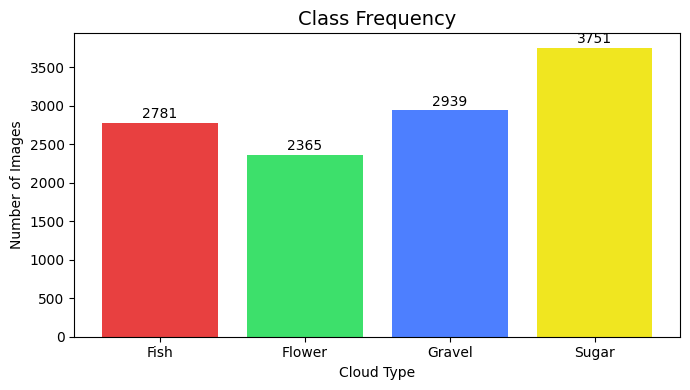

In [7]:
# How many images contain each class
fig, ax = plt.subplots(figsize=(7, 4))
class_counts = presence.sum()
bars = ax.bar(class_counts.index, class_counts.values,
              color=["#e84040", "#3de06b", "#4d7fff", "#f0e620"])
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)
ax.set_title("Class Frequency", fontsize=14)
ax.set_xlabel("Cloud Type")
ax.set_ylabel("Number of Images")
plt.tight_layout()
plt.show()

### Distribution of number of labels

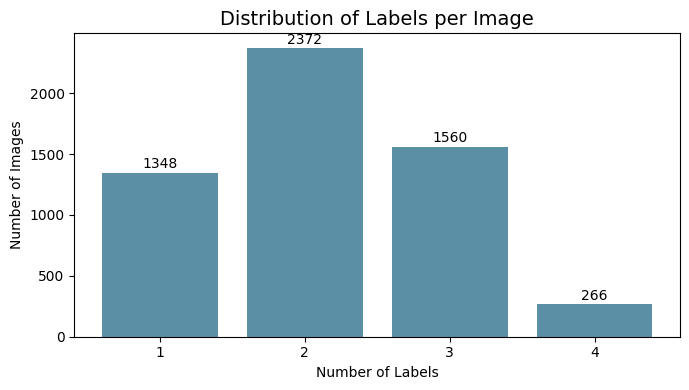

In [8]:
# Distribution of how many labels each image has
fig, ax = plt.subplots(figsize=(7, 4))
label_counts = presence.sum(axis=1).value_counts().sort_index()
bars = ax.bar(label_counts.index, label_counts.values, color="#5b8fa6")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)
ax.set_title("Distribution of Labels per Image", fontsize=14)
ax.set_xlabel("Number of Labels")
ax.set_ylabel("Number of Images")
ax.set_xticks(label_counts.index)
plt.tight_layout()
plt.show()

### Label co-occurence

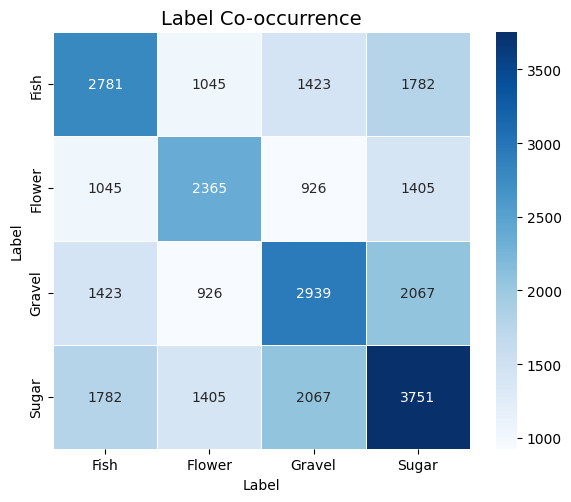

In [11]:
# Label co-occurrence: how often each pair of labels appears together
co = presence.T @ presence

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(co, annot=True, fmt="d", cmap="Blues", ax=ax,
            linewidths=0.5, square=True)
ax.set_title("Label Co-occurrence", fontsize=14)
plt.tight_layout()
plt.show()

### Average mask coverage per class

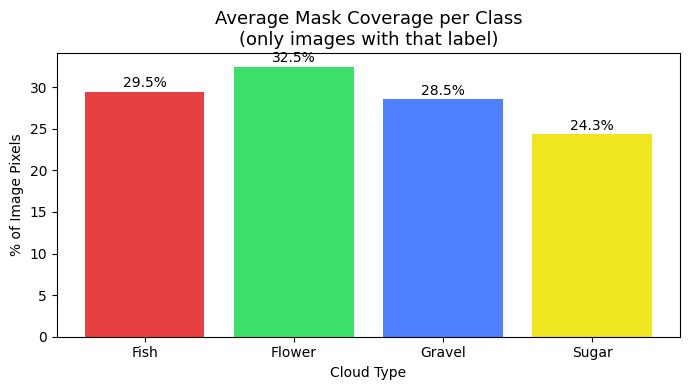

In [12]:
# Average mask coverage per class (among images that have that label)
def rle_pixel_count(rle_string):
    if rle_string == "":
        return 0
    nums = list(map(int, rle_string.split()))
    return sum(nums[1::2])

IMG_HEIGHT, IMG_WIDTH = 1400, 2100
total_pixels = IMG_HEIGHT * IMG_WIDTH

coverage = {
    label: pivot_training_df[label].apply(rle_pixel_count)
    for label in LABELS
}
avg_coverage = {label: coverage[label][coverage[label] > 0].mean() / total_pixels * 100
                for label in LABELS}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(avg_coverage.keys(), avg_coverage.values(),
              color=["#e84040", "#3de06b", "#4d7fff", "#f0e620"])
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)
ax.set_title("Average Mask Coverage per Class\n(only images with that label)", fontsize=13)
ax.set_xlabel("Cloud Type")
ax.set_ylabel("% of Image Pixels")
plt.tight_layout()
plt.show()

## Plotting some images

In [13]:
def rle_to_mask(rle_string, height, width):
    if rle_string == "":
        return np.zeros((height, width))
    nums = [int(x) for x in rle_string.split()]
    pairs = np.array(nums).reshape(-1, 2)
    mask = np.zeros(height * width, dtype=np.uint8)
    for index, length in pairs:
        index -= 1
        mask[index:index + length] = 255
    return mask.reshape(width, height).T / 255.0

In [14]:
font_prop = font_manager.FontProperties(size = 14, weight = "semibold")

def draw_label(mask, label, ax):
    if np.sum(mask) > 0:
        y, x = np.argwhere(mask == 1)[0]
        ax.text(x + 20, y + 50, label, color='white', fontproperties=font_prop)

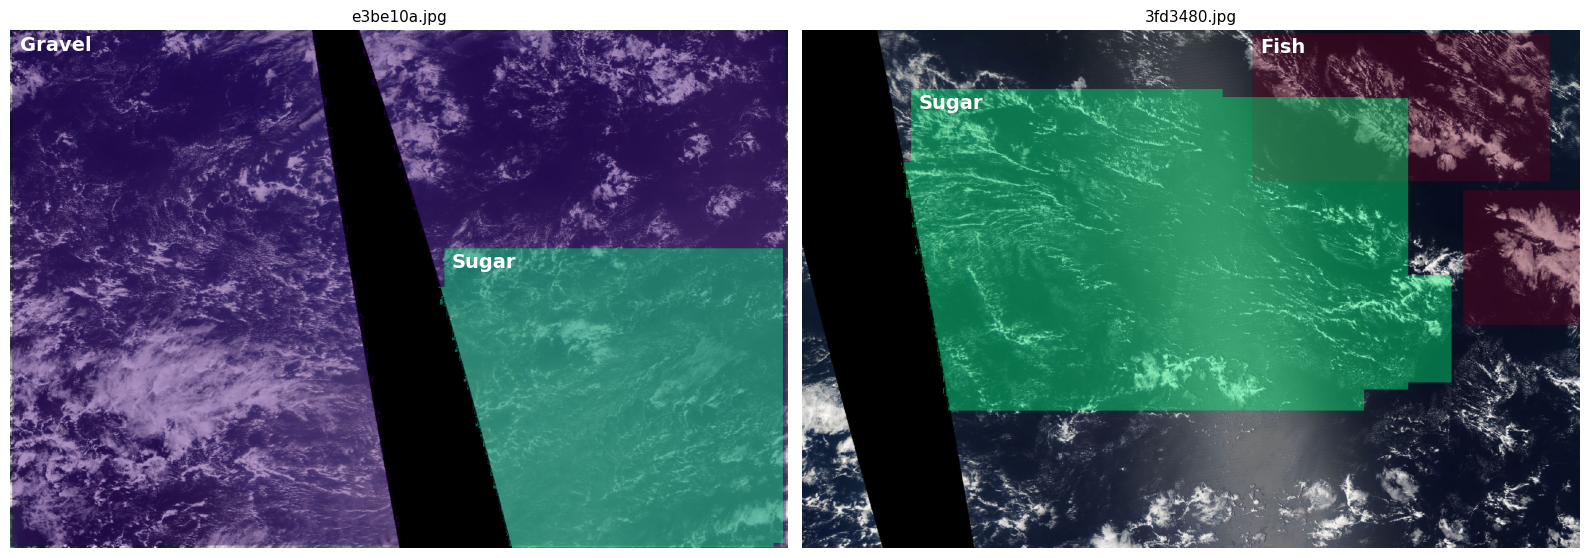

In [18]:
color_map = {
    "Fish": "PuRd_r", 
    "Flower": "Blues_r", 
    "Gravel": "Purples_r", 
    "Sugar": "winter_r"
}

images_path = "data/train_images"

sample = pivot_training_df[
    (pivot_training_df != "").any(axis=1)
].sample(2, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (img_name, row) in zip(axes, sample.iterrows()):
    img = imread(os.path.join(images_path, img_name))
    h, w = img.shape[:2]
    ax.imshow(img)

    for label, cmap in color_map.items():
        mask = rle_to_mask(row[label], h, w)
        mask = np.clip(mask, 0, 1)
        masked = np.ma.masked_where(mask == 0, mask)
        ax.imshow(masked, alpha=0.4, cmap=cmap)
        draw_label(mask, label, ax)

    ax.set_title(img_name, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

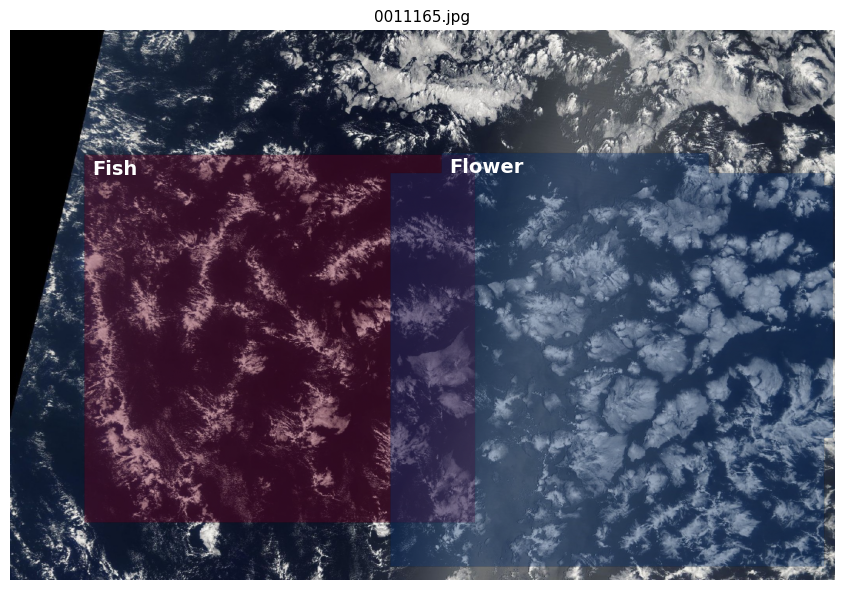

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

images_path = "data/train_images"
img_name = "0011165.jpg"
img = imread(os.path.join(images_path, img_name))
h, w = img.shape[:2]
ax.imshow(img)


for label, cmap in color_map.items():
    mask = rle_to_mask(pivot_training_df.loc[img_name, label], h, w)
    mask = np.clip(mask, 0, 1)
    masked = np.ma.masked_where(mask == 0, mask)
    ax.imshow(masked, alpha=0.4, cmap=cmap)
    draw_label(mask, label, ax)

ax.set_title(img_name, fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()